# PDB Structure Explorer

## Purpose:

This project uses Python and Biopython to explore how a determined protein structure is organized inside a Protein Data Bank file.

The structure selected for this project is **3HS4**, human carbonic anhydrase II, in complex with the inhibitor acetazolamide.

## Question:

How can Python distinguish the protein, ligand, metal ion, water molecules, crystallization additives, residues, and atoms present in a PDB structure. 

## Objectives:

- Download a real experimental PDB structure
- Verify the download coordinate file
- Parse the file using Biopython
- Explore models, chains, residues, and atoms
- Separate standard protein residues from nonstandar components
- Identify acetazolamide, zinc, glycerol, and water
- Inspect atomic coordinates
- Calculate simple atom to atom distances
- Create structure composition tables and figures

## Scope:

This project focuses on understanding and validating the contents of one PDB file. It does not perform a complete protein-ligand contact analysis. 

In [1]:
from pathlib import Path
import requests
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser 

In [2]:
PDB_ID = "3HS4"
DATA_DIR = Path("Data")
RESULTS_DIR = Path("Results")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("PBB structure:", PDB_ID)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Data directory exists:", DATA_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

PBB structure: 3HS4
Data directory: Data
Results directory: Results
Data directory exists: True
Results directory exists: True


In [3]:
def download_pdb(pdb_id, data_directory):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    output_path = data_directory / f"{pdb_id}.pdb"
    if output_path.exists():
        print(f"{output_path} already exists. Skipping download.") 
        return output_path

    print(f"Downloading {pdb_id}")
    print(f"URL: {url}")
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    output_path.write_text(response.text, encoding="utf-8")
    print(f"Saved structure to: {output_path}")
    return output_path

In [4]:
pdb_path = download_pdb(PDB_ID, DATA_DIR)
print("Local PDB path:", pdb_path)

Data\3HS4.pdb already exists. Skipping download.
Local PDB path: Data\3HS4.pdb


In [5]:
print("DOWNLOAD VALIDATION")
print("-------------------")
print("Expected path:", pdb_path)
print("Absolute path:", pdb_path.resolve())
print("File exists:", pdb_path.exists())
print("File size:", pdb_path.stat().st_size, "bytes")

DOWNLOAD VALIDATION
-------------------
Expected path: Data\3HS4.pdb
Absolute path: C:\Users\cruze\Exploring-PBD-Structures\Data\3HS4.pdb
File exists: True
File size: 441570 bytes


In [6]:
print("FIRST 10 LINES OF THE PDB FILE")
print("------------------------------")
with pdb_path.open("r", encoding="utf-8") as pdb_file:
    for line_number in range(10):
        line = pdb_file.readline()
        print(line.rstrip())

FIRST 10 LINES OF THE PDB FILE
------------------------------
HEADER    LYASE                                   10-JUN-09   3HS4
TITLE     HUMAN CARBONIC ANHYDRASE II COMPLEXED WITH ACETAZOLAMIDE
COMPND    MOL_ID: 1;
COMPND   2 MOLECULE: CARBONIC ANHYDRASE 2;
COMPND   3 CHAIN: A;
COMPND   4 SYNONYM: CARBONIC ANHYDRASE II, CA-II, CARBONATE DEHYDRATASE II,
COMPND   5 CARBONIC ANHYDRASE C, CAC;
COMPND   6 EC: 4.2.1.1;
COMPND   7 ENGINEERED: YES
SOURCE    MOL_ID: 1;


In [7]:
pdb_text = pdb_path.read_text(encoding="utf-8")
print("Characters in PDB file:", len(pdb_text))
print("Contains structure ID 3HS4:", "3HS4" in pdb_text)

Characters in PDB file: 436185
Contains structure ID 3HS4: True


In [8]:
assert PDB_ID in pdb_text, "The expected PDB identifier was not found in the file"
assert "CARBONIC ANHYDRASE" in pdb_text.upper(), "The expected protein name was not found in the file"
print("PDB identity validation passed.")

PDB identity validation passed.


## Parsing the PDB coordinate file

The downloaded PDB file is a structured text file. Biopython's `PDBParser` converts the text records into linked Python objects representing the structure, models, chains, residues, and atoms.

This makes it possible to navigate the molecular structure using biological levels rather than processing every text line manually.

In [9]:
parser = PDBParser(QUIET=True)
print("PDB parser created successfully")

PDB parser created successfully


In [10]:
structure = parser.get_structure(PDB_ID, pdb_path)
print("Parsed structure:", structure)
print("Structure ID:", structure.id)

Parsed structure: <Structure id=3HS4>
Structure ID: 3HS4


In [11]:
assert structure.id == PDB_ID, "The parsed structure ID does not match the expected PDB ID"
print("Parsed structure validation passed.")

Parsed structure validation passed.


## Exploring structural models

A PDB structure can contain one or more coordinate models. A model is a complete set of molecular coordinates within the structural hierarchy. This is a PDB hierarchy level that contains chains and their coordinates.

In [12]:
models = list(structure.get_models())
print("Number of models:", len(models))

Number of models: 1


In [13]:
for model in models:
    print("Model ID:", model.id)

Model ID: 0


In [14]:
model = structure[0]
print("Selected model:", model.id)

Selected model: 0


In [15]:
assert len(models) > 0, "No structural models were found"
assert model.id == 0, "The selected model does not have ID 0"
print("Model selection passed validation.")

Model selection passed validation.


## Exploring the molecular chains

Chains organize residues into molecular components or polymer segments. Chain identifiers are usually letters, although the exact identifiers depend on the PDB entry.

The selected structure is expected to contain one main carbonic anhydrase protein chain.

In [16]:
chains = list(model.get_chains())
print("Number of chains:", len(chains))

Number of chains: 1


In [17]:
chain_ids = [chain.id for chain in chains]
print("Chain IDs:", chain_ids)

Chain IDs: ['A']


In [18]:
chain_a = model["A"]
print("Selected chain:", chain_a.id)

Selected chain: A


In [19]:
assert "A" in chain_ids, "Chain A was not found in the structure"
assert chain_a.id == "A", "The selected chain is not chain A"
print("Chain A selection passed validation.")

Chain A selection passed validation.


## Explore residues in chain A

A residue is a group of atoms treated as one structural unit. Protein amino acids are residues, but PDB files may also represent ligands, ions, additives, and water molecules as residue like objects.

Therefore, not every Biopython `Residue` object is an amino acid.

In [20]:
chain_a_residues = list(chain_a.get_residues())
print("Total residue-like objects in chain A:", len(chain_a_residues))

Total residue-like objects in chain A: 666


In [21]:
for residue in chain_a_residues[:10]:
    print("Name:", residue.resname, "| ID:", residue.id)

Name: HIS | ID: (' ', 4, ' ')
Name: TRP | ID: (' ', 5, ' ')
Name: GLY | ID: (' ', 6, ' ')
Name: TYR | ID: (' ', 7, ' ')
Name: GLY | ID: (' ', 8, ' ')
Name: LYS | ID: (' ', 9, ' ')
Name: HIS | ID: (' ', 10, ' ')
Name: ASN | ID: (' ', 11, ' ')
Name: GLY | ID: (' ', 12, ' ')
Name: PRO | ID: (' ', 13, ' ')


In [22]:
first_residue = chain_a_residues[0]
hetero_flag = first_residue.id[0]
residue_number = first_residue.id[1]
insertion_code = first_residue.id[2]
print("Residue name:", first_residue.resname)
print("Hetero flag:", repr(hetero_flag))
print("Residue number:", residue_number)
print("Insertion code:", repr(insertion_code))

Residue name: HIS
Hetero flag: ' '
Residue number: 4
Insertion code: ' '


## Classify structure components

Biopython stores standard protein residues, ligands, metal ions, additives, and water within the residue hierarchy.

The residue ID's hetero flag can help separate these component types.

In [23]:
standard_residues = [residue for residue in chain_a_residues if residue.id[0] == " "]
print("Number of standard protein residues:", len(standard_residues))

Number of standard protein residues: 257


In [24]:
water_residues = [residue for residue in chain_a_residues if residue.resname == "HOH"]
print("Number of crystallographic water molecules:", len(water_residues))

Number of crystallographic water molecules: 404


In [25]:
nonstandard_components = [residue for residue in chain_a_residues if residue.id[0] != " " and residue.resname != "HOH"]
print("Number of nonstandard, non-water components:", len(nonstandard_components))

Number of nonstandard, non-water components: 5


In [26]:
classified_total = (len(standard_residues) + len(water_residues) + len(nonstandard_components))
print("All residue-like objects:", len(chain_a_residues))
print("Classified residue-like objects:", classified_total)
assert classified_total == len(chain_a_residues), "The component categories do not account for every residue"
print("Component classification passed validation.")

All residue-like objects: 666
Classified residue-like objects: 666
Component classification passed validation.


In [27]:
print("NONSTANDARD COMPONENTS")
print("----------------------")
for component in nonstandard_components:
    print("Name:", component.resname, "| Residue ID:", component.id, "| Atom count:", len(list(component.get_atoms())))

NONSTANDARD COMPONENTS
----------------------
Name: ZN | Residue ID: ('H_ZN', 301, ' ') | Atom count: 1
Name: GOL | Residue ID: ('H_GOL', 400, ' ') | Atom count: 6
Name: AZM | Residue ID: ('H_AZM', 701, ' ') | Atom count: 13
Name: AZM | Residue ID: ('H_AZM', 702, ' ') | Atom count: 13
Name: AZM | Residue ID: ('H_AZM', 703, ' ') | Atom count: 13


In [28]:
nonstandard_component_labels = [f"{component.resname}{component.id[1]}" for component in nonstandard_components]
print("Nonstandard component labels:")
print(nonstandard_component_labels)

Nonstandard component labels:
['ZN301', 'GOL400', 'AZM701', 'AZM702', 'AZM703']


In [29]:
component_names = [component.resname for component in nonstandard_components]
component_name_counts = pd.Series(component_names).value_counts()
print(component_name_counts)

AZM    3
ZN     1
GOL    1
Name: count, dtype: int64


## Exploring atoms and three-dimensional coordinates

Atoms are the lowest level of the Biopython structural hierarchy used in this project.

Each modeled atom contains information such as:

- Atom name
- Chemical element
- Parent residue
- Parent chain
- Three-dimensional coordinates

The coordinates describe the atom's position along the x, y, and z axes in ångströms.

In [30]:
chain_a_atoms = list(chain_a.get_atoms())
print("Number of atoms in chain A:", len(chain_a_atoms))

Number of atoms in chain A: 2499


In [31]:
first_atom = chain_a_atoms[0]
print("Atom object:", first_atom)
print("Atom name:", first_atom.name)
print("Element:", first_atom.element)
print("Coordinates:", first_atom.coord)

Atom object: <Atom N>
Atom name: N
Element: N
Coordinates: [9.616 1.832 9.162]


In [32]:
parent_residue = first_atom.get_parent()
print("Parent residue name:", parent_residue.resname)
print("Parent residue ID:", parent_residue.id)

Parent residue name: HIS
Parent residue ID: (' ', 4, ' ')


In [33]:
parent_chain = parent_residue.get_parent()
print("Parent chain:", parent_chain.id)

Parent chain: A


In [34]:
print("ATOM DESCRIPTION")
print("----------------")
print("Chain:", parent_chain.id)
print("Residue name:", parent_residue.resname)
print("Residue number:", parent_residue.id[1])
print("Atom name:", first_atom.name)
print("Element:", first_atom.element)
print("Coordinates:", first_atom.coord)

ATOM DESCRIPTION
----------------
Chain: A
Residue name: HIS
Residue number: 4
Atom name: N
Element: N
Coordinates: [9.616 1.832 9.162]


In [35]:
protein_atoms = [atom for residue in standard_residues for atom in residue.get_atoms()]
print("Number of protein atoms:", len(protein_atoms))

Number of protein atoms: 2049


In [36]:
for atom in protein_atoms[:10]:
    residue = atom.get_parent()
    print(f"{residue.resname}{residue.id[1]}", "| Atom:", atom.name, "| Element:", atom.element, "| Coordinates:", atom.coord)

HIS4 | Atom: N | Element: N | Coordinates: [9.616 1.832 9.162]
HIS4 | Atom: CA | Element: C | Coordinates: [9.498 0.519 8.491]
HIS4 | Atom: C | Element: C | Coordinates: [ 9.067 -0.632  9.398]
HIS4 | Atom: O | Element: O | Coordinates: [ 9.467 -1.812  9.289]
HIS4 | Atom: CB | Element: C | Coordinates: [10.83   0.117  7.879]
HIS4 | Atom: CG | Element: C | Coordinates: [11.237  1.238  6.975]
HIS4 | Atom: ND1 | Element: N | Coordinates: [11.899  2.341  7.442]
HIS4 | Atom: CD2 | Element: C | Coordinates: [11.059  1.437  5.653]
HIS4 | Atom: CE1 | Element: C | Coordinates: [12.139  3.188  6.443]
HIS4 | Atom: NE2 | Element: N | Coordinates: [11.631  2.649  5.336]


## Summarizing nonstandard structure components

The PDB structure contains objects other than standard protein residues.

Each nonstandard component will be summarized using:

- Component name
- Residue number
- Hetero flag
- Atom count
- Atom elements

This table helps distinguish the inhibitor, catalytic metal, crystallization additives, and other nonprotein components.

In [37]:
component_rows = []
for component in nonstandard_components:
    component_atoms = list(component.get_atoms())
    component_elements = sorted({atom.element for atom in component_atoms})
    component_row = {"chain_id": component.get_parent().id, "component_name": component.resname, "residue_number": component.id[1], "hetero_flag": component.id[0], "atom_count": len(component_atoms), "elements": ", ".join(component_elements)}
    component_rows.append(component_row)
print("Component records created:", len(component_rows))

Component records created: 5


In [38]:
nonstandard_component_table = pd.DataFrame(component_rows)
nonstandard_component_table

,chain_id,component_name,residue_number,hetero_flag,atom_count,elements
0,A,ZN,301,H_ZN,1,ZN
1,A,GOL,400,H_GOL,6,"C, O"
2,A,AZM,701,H_AZM,13,"C, N, O, S"
3,A,AZM,702,H_AZM,13,"C, N, O, S"
4,A,AZM,703,H_AZM,13,"C, N, O, S"


In [39]:
assert len(nonstandard_component_table) == len(nonstandard_components), "Some nonstandard components are missing from the table"
assert nonstandard_component_table["component_name"].notna().all(), "At least one component is missing a name"
assert (nonstandard_component_table["atom_count"] > 0).all(), "At least one component contains no atoms"
print("Nonstandard component table passed validation.")

Nonstandard component table passed validation.


In [40]:
nonstandard_components_path = (RESULTS_DIR / "Nonstandard_Components.csv")
nonstandard_component_table.to_csv(nonstandard_components_path, index=False)
print("Nonstandard component table saved to:", nonstandard_components_path)

Nonstandard component table saved to: Results\Nonstandard_Components.csv


In [41]:
print("Unique nonstandard component names:")

print(sorted(nonstandard_component_table["component_name"].unique()))

Unique nonstandard component names:
['AZM', 'GOL', 'ZN']


In [42]:
zinc_residues = [component for component in nonstandard_components if component.resname == "ZN"]
print("Number of zinc residues:", len(zinc_residues))

Number of zinc residues: 1


In [43]:
assert len(zinc_residues) > 0, "No zinc ion was identified"
print("Zinc selection passed validation.")

Zinc selection passed validation.


In [44]:
zinc_atoms = [atom for zinc_residue in zinc_residues for atom in zinc_residue.get_atoms()]
print("Number of zinc atoms:", len(zinc_atoms))

Number of zinc atoms: 1


In [45]:
zinc_atom = zinc_atoms[0]
print("Zinc atom name:", zinc_atom.name)
print("Zinc element:", zinc_atom.element)
print("Zinc coordinates:", zinc_atom.coord)

Zinc atom name: ZN
Zinc element: ZN
Zinc coordinates: [-6.72  -1.684 15.288]


In [46]:
assert zinc_atom.element.upper() == "ZN", "The selected atom is not zinc"
print("Zinc atom validation passed.")

Zinc atom validation passed.


In [47]:
azm_residues = [component for component in nonstandard_components if component.resname == "AZM"]
print("Number of acetazolamide residues:", len(azm_residues))

Number of acetazolamide residues: 3


In [48]:
for azm_residue in azm_residues:
    print("Chain:", azm_residue.get_parent().id, "| Residue ID:", azm_residue.id, "| Atom count:", len(list(azm_residue.get_atoms())))

Chain: A | Residue ID: ('H_AZM', 701, ' ') | Atom count: 13
Chain: A | Residue ID: ('H_AZM', 702, ' ') | Atom count: 13
Chain: A | Residue ID: ('H_AZM', 703, ' ') | Atom count: 13


In [49]:
first_azm_residue = azm_residues[0]
first_azm_atoms = list(first_azm_residue.get_atoms())
first_azm_atom = first_azm_atoms[0]
distance_to_zinc = zinc_atom - first_azm_atom
print("AZM atom:", first_azm_atom.name)
print("Zinc atom:", zinc_atom.name)
print("Atom-to-atom distance:", distance_to_zinc, "angstroms")

AZM atom: C1
Zinc atom: ZN
Atom-to-atom distance: 4.132553 angstroms


In [50]:
first_azm_distances = [zinc_atom - azm_atom for azm_atom in first_azm_atoms]
print("Number of distances:", len(first_azm_distances))
print("Minimum distance:", min(first_azm_distances))
print("Maximum distance:", max(first_azm_distances))

Number of distances: 13
Minimum distance: 1.9401691
Maximum distance: 9.081208


In [51]:
closest_first_azm_atom = min(first_azm_atoms, key=lambda azm_atom: zinc_atom - azm_atom)
closest_first_azm_distance = (zinc_atom - closest_first_azm_atom)
print("Closest AZM atom:", closest_first_azm_atom.name)
print("Closest distance to zinc:", closest_first_azm_distance, "angstroms")

Closest AZM atom: N1
Closest distance to zinc: 1.9401691 angstroms


In [52]:
azm_distance_rows = []
for azm_residue in azm_residues:
    azm_atoms = list(azm_residue.get_atoms())
    closest_azm_atom = min(azm_atoms,key=lambda azm_atom: zinc_atom - azm_atom)
    minimum_distance = (zinc_atom - closest_azm_atom)
    azm_distance_row = {"chain_id": azm_residue.get_parent().id, "azm_residue_number": azm_residue.id[1], "closest_azm_atom": closest_azm_atom.name, "minimum_distance_to_zinc_angstrom": round(float(minimum_distance),3)}
    azm_distance_rows.append(azm_distance_row)
print("AZM distance records created:", len(azm_distance_rows))

AZM distance records created: 3


In [53]:
azm_distance_table = pd.DataFrame(azm_distance_rows)
azm_distance_table

,chain_id,azm_residue_number,closest_azm_atom,minimum_distance_to_zinc_angstrom
0,A,701,N1,1.940
1,A,702,N1,17.308
2,A,703,O1,16.621


In [54]:
azm_distance_table = (azm_distance_table.sort_values("minimum_distance_to_zinc_angstrom").reset_index(drop=True))
azm_distance_table

,chain_id,azm_residue_number,closest_azm_atom,minimum_distance_to_zinc_angstrom
0,A,701,N1,1.940
1,A,703,O1,16.621
2,A,702,N1,17.308


In [55]:
closest_azm_record = azm_distance_table.iloc[0]
print("Closest AZM record:", closest_azm_record)

Closest AZM record: chain_id                                A
azm_residue_number                    701
closest_azm_atom                       N1
minimum_distance_to_zinc_angstrom    1.94
Name: 0, dtype: object


In [56]:
active_site_azm_number = int(closest_azm_record["azm_residue_number"])
active_site_closest_atom_name = (closest_azm_record["closest_azm_atom"])
active_site_zinc_distance = float(closest_azm_record["minimum_distance_to_zinc_angstrom"])
print("Likely active-site AZM residue number:", active_site_azm_number)
print("Closest AZM atom to zinc:", active_site_closest_atom_name)
print("Minimum AZM-zinc distance:", active_site_zinc_distance, "angstroms")

Likely active-site AZM residue number: 701
Closest AZM atom to zinc: N1
Minimum AZM-zinc distance: 1.94 angstroms


In [57]:
assert len(azm_distance_table) == len(azm_residues), "Not every AZM copy was included"
assert azm_distance_table["minimum_distance_to_zinc_angstrom"].is_monotonic_increasing, ("The AZM distance table is not sorted correctly")
assert active_site_zinc_distance > 0, "The minimum distance must be positive"
print("AZM-zinc distance analysis passed validation.")

AZM-zinc distance analysis passed validation.


In [58]:
azm_distance_path = (RESULTS_DIR / "Acetazolamide_Zinc_Distances.csv")
azm_distance_table.to_csv(azm_distance_path,index=False)
print("AZM-zinc distance table saved to:", azm_distance_path)

AZM-zinc distance table saved to: Results\Acetazolamide_Zinc_Distances.csv


## Summarizing the structure composition

The residue-like objects in chain A are divided into three broad categories:

- Standard protein residues
- Crystallographic water molecules
- Nonstandard, non-water components

The nonstandard category includes molecules such as acetazolamide, zinc, glycerol, and any other nonprotein components represented in the coordinate file.

In [59]:
structure_composition = pd.DataFrame({"component_category": ["Standard protein residues","Water molecules", "Nonstandard components"],"residue_count":[len(standard_residues), len(water_residues), len(nonstandard_components)]})
structure_composition

,component_category,residue_count
0,Standard protein residues,257
1,Water molecules,404
2,Nonstandard components,5


In [60]:
assert len(structure_composition) == 3, "The composition table should contain three categories"
assert (structure_composition["residue_count"].sum() == len(chain_a_residues)), "The composition counts do not equal the total residue-like object count"
assert (structure_composition["residue_count"] >= 0).all(), "A residue count cannot be negative"
print("Structure-composition table passed validation.")

Structure-composition table passed validation.


In [61]:
structure_composition_path = (RESULTS_DIR / "Structure_Composition.csv")
structure_composition.to_csv(structure_composition_path, index=False)
print("Structure composition saved to:", structure_composition_path)

Structure composition saved to: Results\Structure_Composition.csv


## Building a chain-level summary

A chain-level summary reports how many standard residues, waters, nonstandard components, and atoms belong to each chain.

Although 3HS4 contains one main protein chain, the same workflow can be applied to structures containing multiple chains.

In [62]:
chain_summary_rows = []

for chain in chains:
    chain_residues = list(chain.get_residues())
    chain_atoms = list(chain.get_atoms())
    chain_standard_residues = [residue for residue in chain_residues if residue.id[0] == " "]
    chain_waters = [residue for residue in chain_residues if residue.resname == "HOH"]
    chain_nonstandard_components = [residue for residue in chain_residues if residue.id[0] != " " and residue.resname != "HOH"]
    chain_summary_row = {"chain_id": chain.id, "standard_residue_count": len(chain_standard_residues), "water_count": len(chain_waters), "nonstandard_component_count": len(chain_nonstandard_components),"total_residue_like_objects": len(chain_residues),"total_atom_count": len(chain_atoms)}
    
chain_summary_rows.append(chain_summary_row)
print("Chain summary rows created:", len(chain_summary_rows))

Chain summary rows created: 1


In [63]:
chain_summary_table = pd.DataFrame(chain_summary_rows)
chain_summary_table

,chain_id,standard_residue_count,water_count,nonstandard_component_count,total_residue_like_objects,total_atom_count
0,A,257,404,5,666,2499


In [64]:
assert len(chain_summary_table) == len(chains), "The chain summary does not include every chain"
assert (chain_summary_table["standard_residue_count"]+ chain_summary_table["water_count"]+ chain_summary_table["nonstandard_component_count"]== chain_summary_table["total_residue_like_objects"]).all(), "At least one chain has inconsistent residue counts"
assert (chain_summary_table["total_atom_count"] > 0).all(), "At least one chain has no atoms"
print("Chain-summary validation passed.")

Chain-summary validation passed.


In [65]:
chain_summary_path = (RESULTS_DIR / "Chain_Summary.csv")
chain_summary_table.to_csv(chain_summary_path, index=False)
print("Chain summary saved to:", chain_summary_path)

Chain summary saved to: Results\Chain_Summary.csv


## Visualizing the structure composition

This figure summarizes the broad types of residue-like objects identified in chain A of 3HS4.

The categories describe how components are represented in the PDB hierarchy. They do not indicate molecular mass, biological importance, or binding
strength.

In [66]:
composition_colors = ["#0072B2", "#56B4E9", "#D55E00"]

Structure-composition figure saved to: Results\Structure_Composition.png


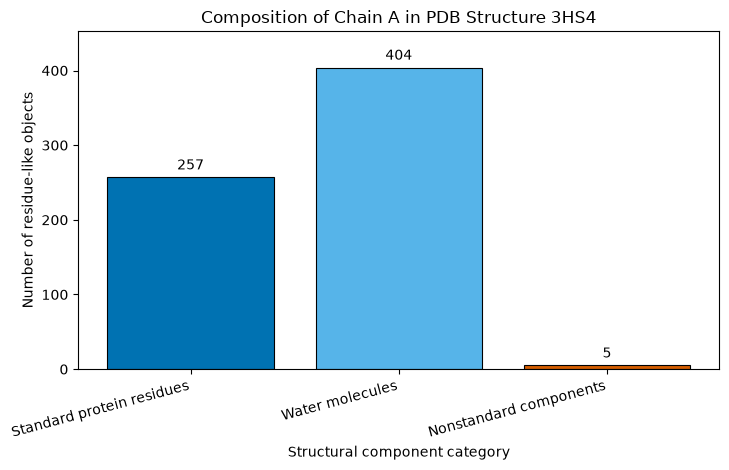

In [67]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(structure_composition["component_category"],structure_composition["residue_count"], color=composition_colors, edgecolor="black", linewidth=0.8)

ax.set_title("Composition of Chain A in PDB Structure 3HS4")
ax.set_xlabel("Structural component category")
ax.set_ylabel("Number of residue-like objects")
maximum_count = structure_composition["residue_count"].max()
ax.set_ylim(0,maximum_count * 1.12) 
for bar, count in zip(bars, structure_composition["residue_count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + maximum_count * 0.015, str(count), ha="center", va="bottom")
    
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

composition_figure_path = (RESULTS_DIR / "Structure_Composition.png")
fig.savefig(composition_figure_path, dpi=150, bbox_inches="tight")
print("Structure-composition figure saved to:", composition_figure_path)

plt.show()

In [68]:
azm_distance_table["azm_label"] = ("AZM" + azm_distance_table["azm_residue_number"].astype(str))
azm_distance_table

,chain_id,azm_residue_number,closest_azm_atom,minimum_distance_to_zinc_angstrom,azm_label
0,A,701,N1,1.940,AZM701
1,A,703,O1,16.621,AZM703
2,A,702,N1,17.308,AZM702


## Comparing acetazolamide distances to zinc

The structure contains multiple acetazolamide records. For each copy, the shortest distance between any acetazolamide atom and the catalytic zinc atom is calculated.

The acetazolamide copy with the shortest zinc distance is interpreted as the likely active-site inhibitor. This conclusion uses both structural geometry and the known zinc-containing active site of carbonic anhydrase.

AZM-zinc distance figure saved to: Results\Acetazolamide_Zinc_Distances.png


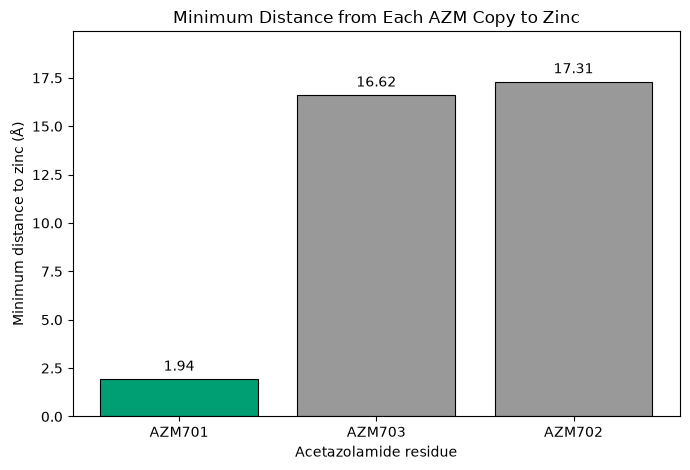

In [69]:
distance_colors = ["#009E73" if index == 0 else "#999999" for index in range(len(azm_distance_table))]

fig, ax = plt.subplots(figsize=(7, 4.8))

bars = ax.bar(azm_distance_table["azm_label"], azm_distance_table["minimum_distance_to_zinc_angstrom"], color=distance_colors, edgecolor="black", linewidth=0.8)

ax.set_title("Minimum Distance from Each AZM Copy to Zinc")
ax.set_xlabel("Acetazolamide residue")
ax.set_ylabel("Minimum distance to zinc (Å)")
maximum_distance = azm_distance_table["minimum_distance_to_zinc_angstrom"].max()

ax.set_ylim(0,maximum_distance * 1.15)
for bar, distance in zip(bars, azm_distance_table["minimum_distance_to_zinc_angstrom"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + maximum_distance * 0.015, f"{distance:.2f}", ha="center", va="bottom")

azm_distance_figure_path = (RESULTS_DIR / "Acetazolamide_Zinc_Distances.png")
fig.savefig(azm_distance_figure_path, dpi=150, bbox_inches="tight")
print("AZM-zinc distance figure saved to:", azm_distance_figure_path)

plt.tight_layout()
plt.show()

In [70]:
output_files = [nonstandard_components_path, azm_distance_path, structure_composition_path, chain_summary_path, composition_figure_path, azm_distance_figure_path]

In [71]:
print("FINAL OUTPUT CHECK")
print("------------------")

for output_file in output_files:
    print(output_file, "| exists:", output_file.exists(), "| size:", output_file.stat().st_size if output_file.exists() else 0,"bytes")

FINAL OUTPUT CHECK
------------------
Results\Nonstandard_Components.csv | exists: True | size: 217 bytes
Results\Acetazolamide_Zinc_Distances.csv | exists: True | size: 129 bytes
Results\Structure_Composition.csv | exists: True | size: 112 bytes
Results\Chain_Summary.csv | exists: True | size: 139 bytes
Results\Structure_Composition.png | exists: True | size: 45779 bytes
Results\Acetazolamide_Zinc_Distances.png | exists: True | size: 34987 bytes


## Interpretation

This project explored the organization of the 3HS4 Protein Data Bank coordinate file using Python and Biopython.

The structure contained one main carbonic anhydrase protein chain together with crystallographic water molecules and several nonstandard components. The nonstandard components included acetazolamide, the catalytic zinc ion, glycerol, and any additional small molecules recorded in the structure.

The analysis demonstrated that not every Biopython `Residue` object represents a protein amino acid. Ligands, metal ions, crystallization additives, and water molecules are also represented within the residue hierarchy and should be
classified.

Multiple acetazolamide copies were present in the coordinate file. Instead of assuming that the first acetazolamide record was the active-site inhibitor, the minimum distance between each acetazolamide copy and the catalytic zinc atom was calculated.

The acetazolamide copy with the shortest zinc distance was interpreted as the likely active-site inhibitor. The other acetazolamide copies were farther from the catalytic metal and may represent additional surface-bound molecules reported in the crystallographic model.

Overall, the project shows how structure metadata, molecular identifiers, and atomic coordinates can be combined to determine what components are present in a PDB file and how those components are organized.

## Conclusion

This project established the structural-data foundations needed for more advanced protein-ligand analysis.

A real experimental PDB file was downloaded, verified, and parsed into Biopython Structure, Model, Chain, Residue, and Atom objects. Standard protein residues were separated from water molecules and nonstandard components.

Atomic names, elements, parent molecular components, and three-dimensional coordinates were inspected. Simple Euclidean distance calculations were then used to compare multiple acetazolamide copies with catalytic zinc and identify the likely active-site inhibitor.